<div style = "border: 1px solid black">
<b><center><font size = "5"> Projecto Prático 1 </font><center></b>

<b><center><font size = "3"> Regressão linear e logística
</font><center></b>
</div>



---



`Nome:` Leonor Rebola <br>
`Número:` 53663 <br>
`Curso:` Inteligência Artificial e Ciência de Dados <br>
`Email:` leonor.rebola@ubi.pt <br>
`UC:` Aprendizagem Computacional <br>


---



`Objetivo:` Verificar se as despesas faturadas pelo seguro de saúde podem ser previstas a partir das restantes características.


---



# **Leitura do ficheiro**

---



In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("insurance.csv")

Saving insurance.csv to insurance.csv


# **Conversão para dados numéricos**

---



In [ ]:
import pandas as pd

def dados_numericos(df):
  # Codificação binária das variáveis categóricas "sex" e "smoker"
  df["sex"] = df["sex"].map({"male": 0, "female": 1})
  df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

  # Divisão entre norte e sul das regiões
  df["Norte/Sul"] = df["region"].map({
    "northeast": 1,
    "northwest": 1,
    "southeast": 0,
    "southwest": 0
  })
  # Divisão entre norte e sul das regiões
  df["Este/Oeste"] = df["region"].map({
    "northeast": 1,
    "southeast": 1,
    "northwest": 0,
    "southwest": 0
  })

  # Remoção da coluna "region"
  df = df.drop(columns=["region"])

  # Visualização dos dados
  print(df.head())
  print(df.info())

  return df

df = dados_numericos(df)

   age  sex     bmi  children  smoker      charges  Norte/Sul  Este/Oeste
0   19    1  27.900         0       1  16884.92400          0           0
1   18    0  33.770         1       0   1725.55230          0           1
2   28    0  33.000         3       0   4449.46200          0           1
3   33    0  22.705         0       0  21984.47061          1           0
4   32    0  28.880         0       0   3866.85520          1           0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   sex         1338 non-null   int64  
 2   bmi         1338 non-null   float64
 3   children    1338 non-null   int64  
 4   smoker      1338 non-null   int64  
 5   charges     1338 non-null   float64
 6   Norte/Sul   1338 non-null   int64  
 7   Este/Oeste  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usag

# **Valores em falta**

---



In [ ]:
import pandas as pd

def dados_em_falta(df):
  # Quantidade de valores nulos
  print (df.isnull().sum())

  # Remove valores nulos
  return df.dropna()

dados_em_falta(df)

age           0
sex           0
bmi           0
children      0
smoker        0
charges       0
Norte/Sul     0
Este/Oeste    0
dtype: int64


,age,sex,bmi,children,smoker,charges,Norte/Sul,Este/Oeste
0,19,1,27.900,0,1,16884.92400,0,0
1,18,0,33.770,1,0,1725.55230,0,1
2,28,0,33.000,3,0,4449.46200,0,1
3,33,0,22.705,0,0,21984.47061,1,0
4,32,0,28.880,0,0,3866.85520,1,0
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0
1334,18,1,31.920,0,0,2205.98080,1,1
1335,18,1,36.850,0,0,1629.83350,0,1
1336,21,1,25.800,0,0,2007.94500,0,0


# **Variáveis estatísticas**

---



In [ ]:
print(df.describe())

               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     39.207025     0.494768    30.663397     1.094918     0.204783   
std      14.049960     0.500160     6.098187     1.205493     0.403694   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.296250     0.000000     0.000000   
50%      39.000000     0.000000    30.400000     1.000000     0.000000   
75%      51.000000     1.000000    34.693750     2.000000     0.000000   
max      64.000000     1.000000    53.130000     5.000000     1.000000   

            charges    Norte/Sul   Este/Oeste  
count   1338.000000  1338.000000  1338.000000  
mean   13270.422265     0.485052     0.514200  
std    12110.011237     0.499963     0.499985  
min     1121.873900     0.000000     0.000000  
25%     4740.287150     0.000000     0.000000  
50%     9382.033000     0.000000     1.000000

# **Histogramas**

---



`Alínea (a):` Gráficos de barras de cada variável

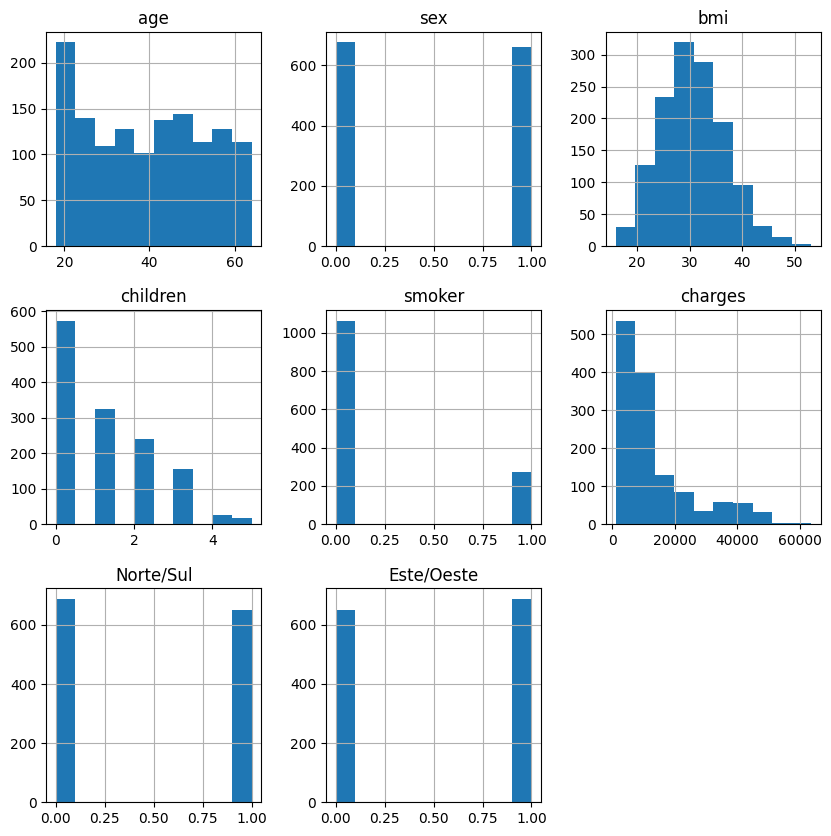

In [ ]:
import matplotlib.pyplot as plt

def barplot(df):
  df.hist(figsize = (10,10))
  plt.subplots_adjust(hspace=0.3, wspace=0.3)
  plt.show()

barplot(df)

***Com base nos gráficos de barras, podemos concluir que:***


*   Existe um equilíbrio entre o número de homens (representados pelo núemro 0) e o número de mulheres (representado pelo número 1);

*   A maioria dos indivíduos não tem filhos;
*   A quantidade de indivíduos que fuma (representados pelo número 1) é inferior à quantidade de indvíduos que não fuma (representados pelo número 0);

*   As despesas em saúde da grande maioria dos indivíduos é inferior a 20000.



`Alínea (b):` Densidade estimada para cada variável

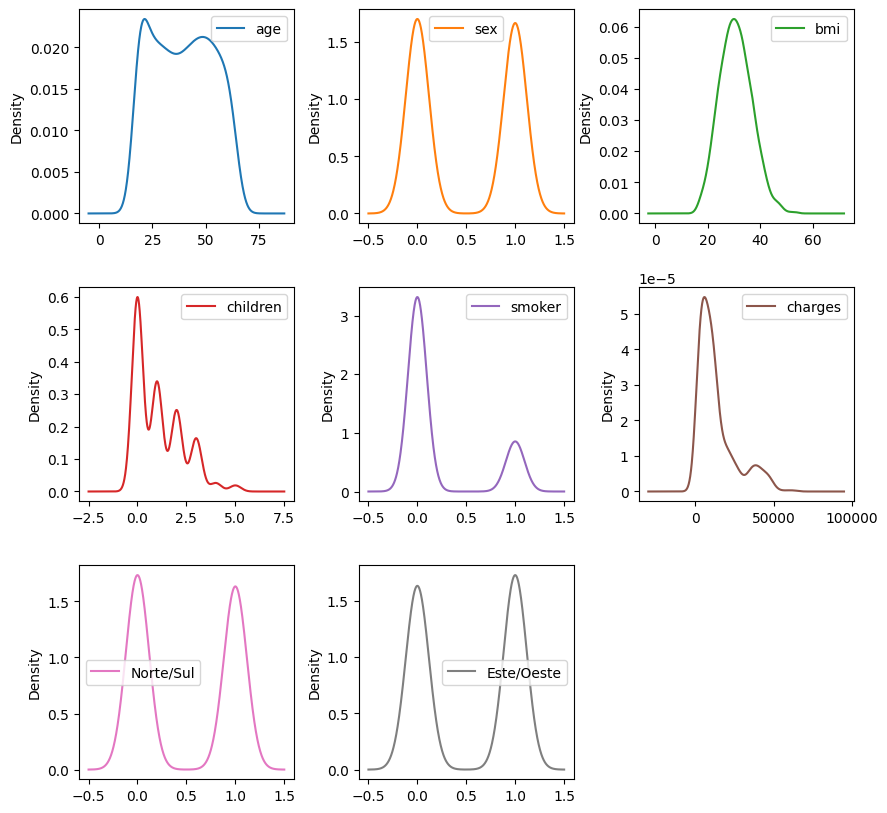

In [ ]:
import matplotlib.pyplot as plt

def density_estimates(df):
  df.plot(kind="density", subplots=True, layout=(3,3), sharex=False, figsize=(10,10))
  plt.subplots_adjust(hspace=0.3, wspace=0.3)
  plt.show()

density_estimates(df)

***Com base nos gráficos de densidade, podemos concluir que:***


*   Existem duas faixas etárias significativas, sendo elas os indivíduos com a idade em torno dos 20 anos e os indivíduos com a idade entre os 30-40 anos;

*   São poucos os indivíduos com quantidade de filhos superior a 3, não tendo filhos muitos deles;

*   A maioria da população não fuma;

*   A maioria dos indivíduos não tem despesas em saúde acima dos 50000;



# **Correlação**

---



`Scatterplots`

`Alínea (a):` Visualização com todas
as variáveis

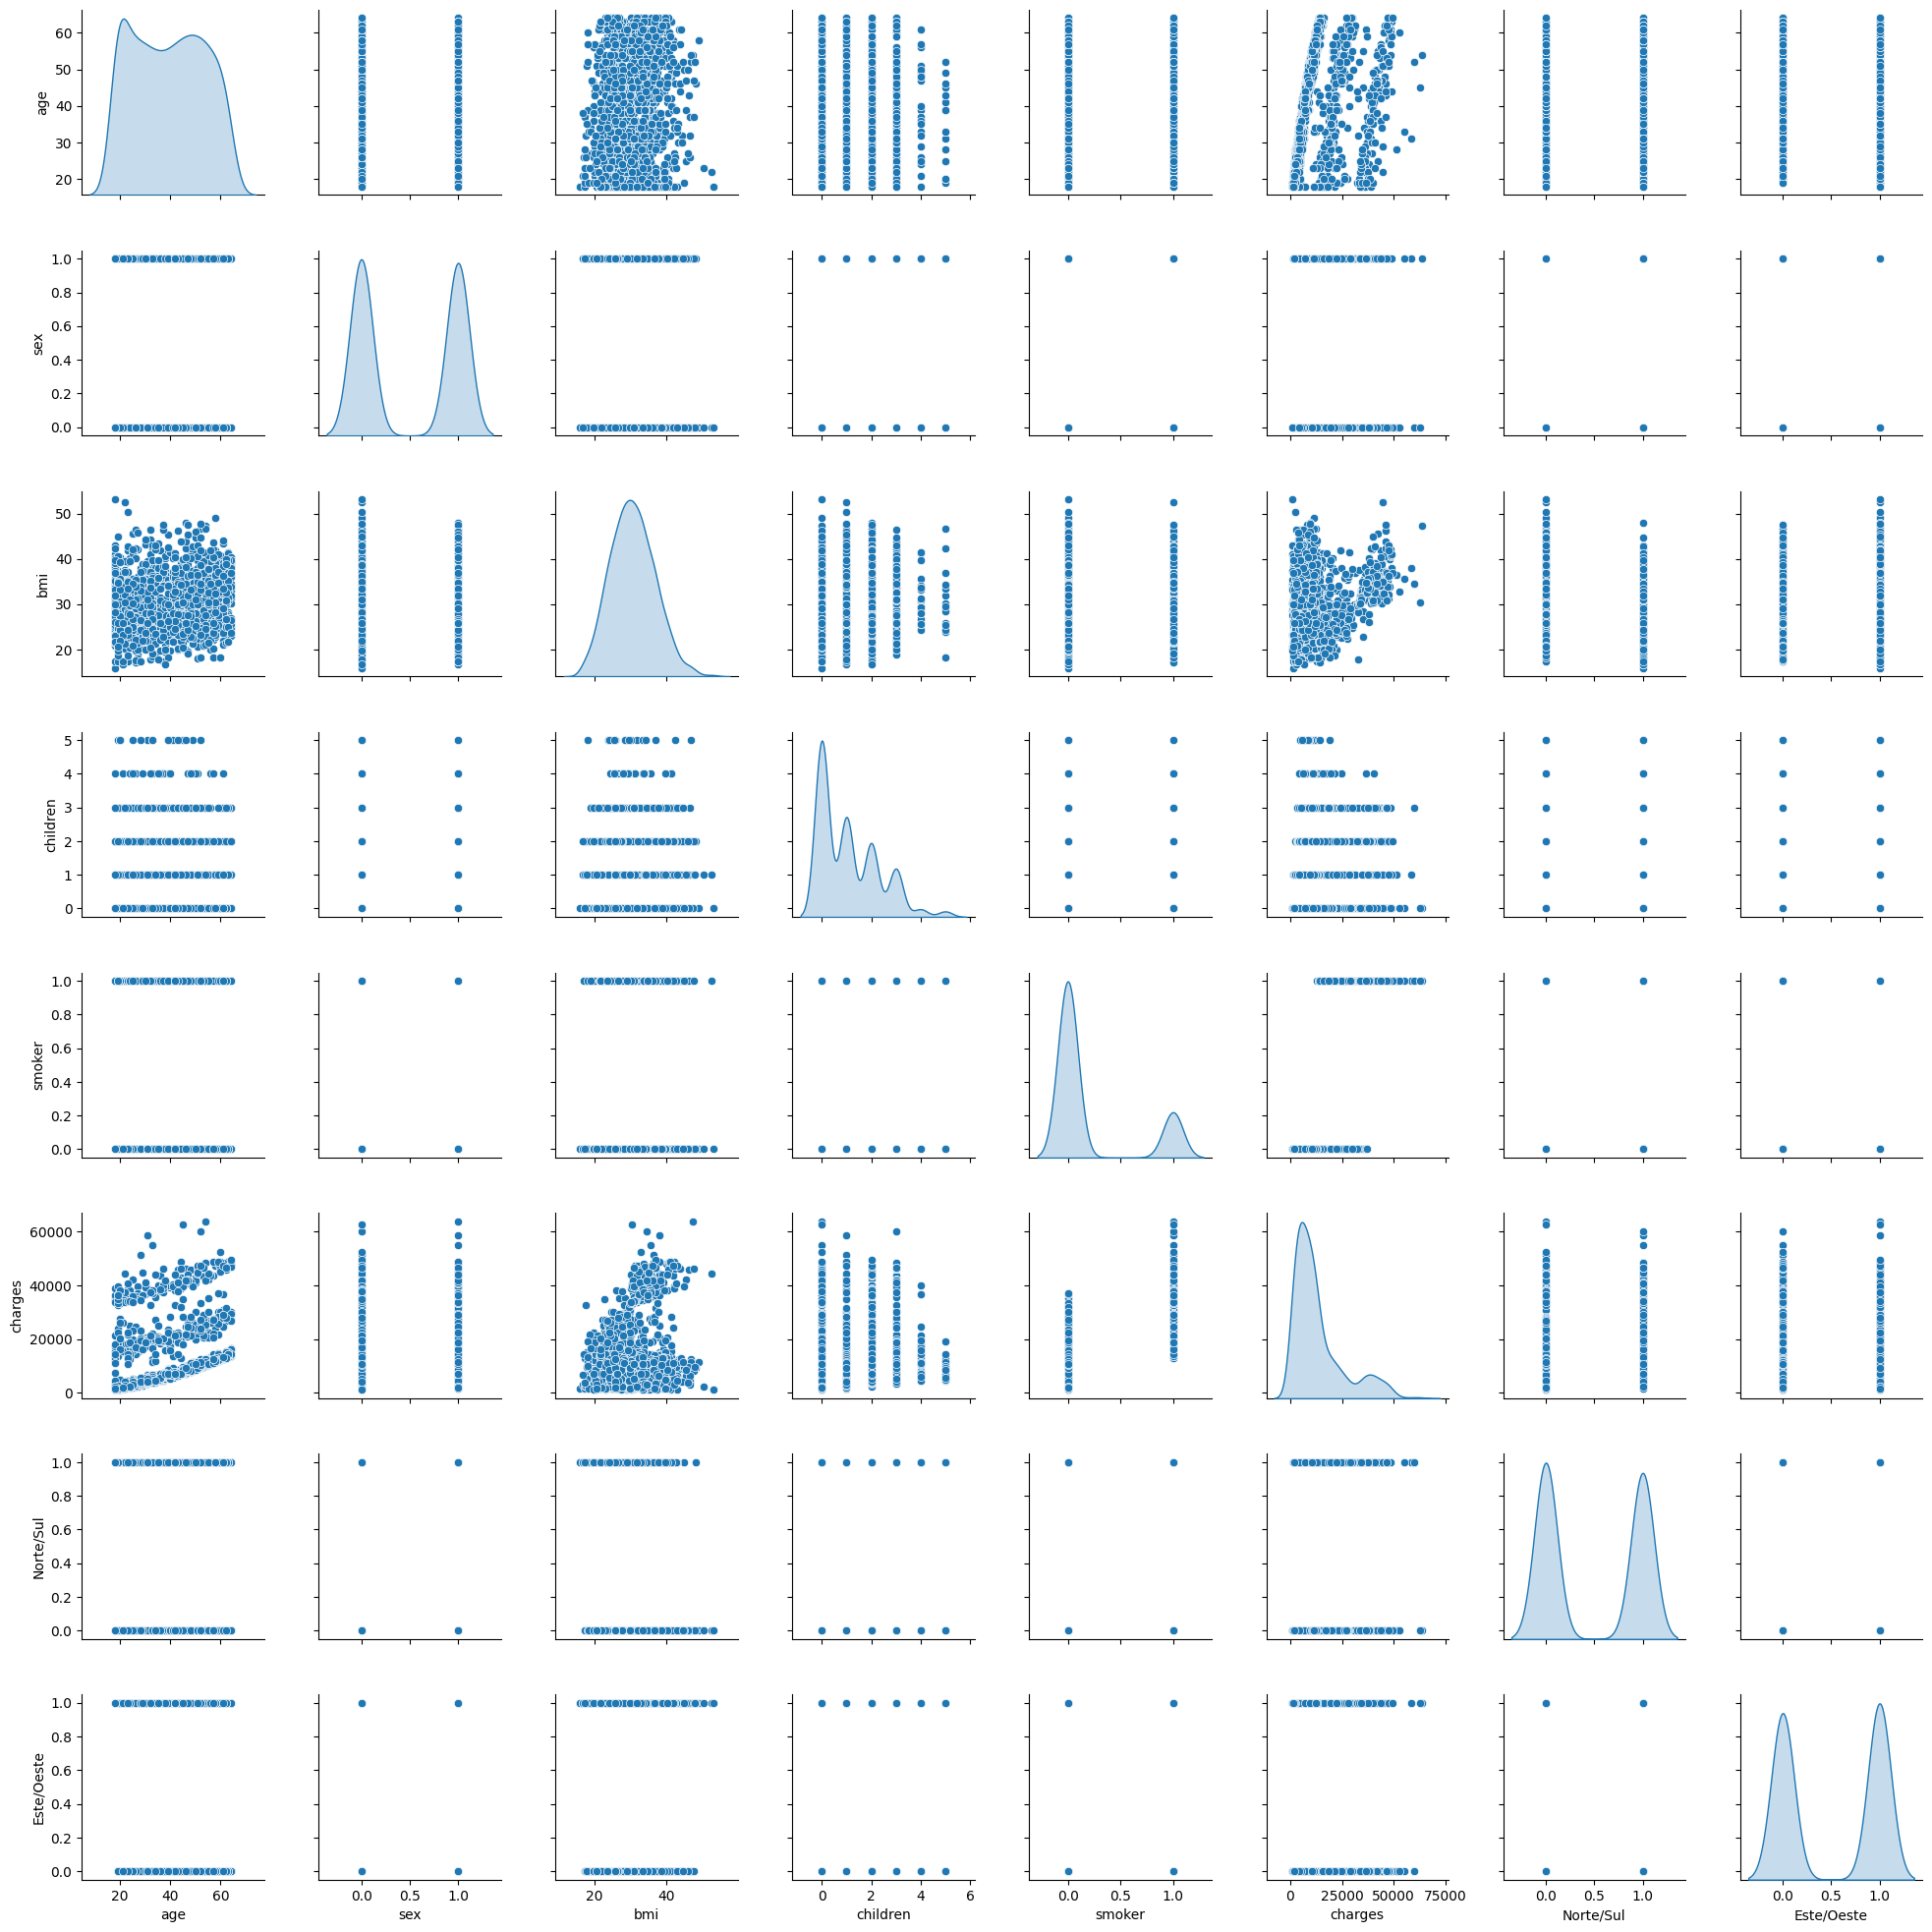

In [ ]:
import seaborn as sns

def scatterplot(df):
  g = sns.pairplot(df, diag_kind="kde", height=2.5)
  g.fig.subplots_adjust(hspace=0.3, wspace=0.3)
  plt.show()

scatterplot(df)

`Alínea (b):` Visualização com a variável dependente

**Variável dependente = charges**

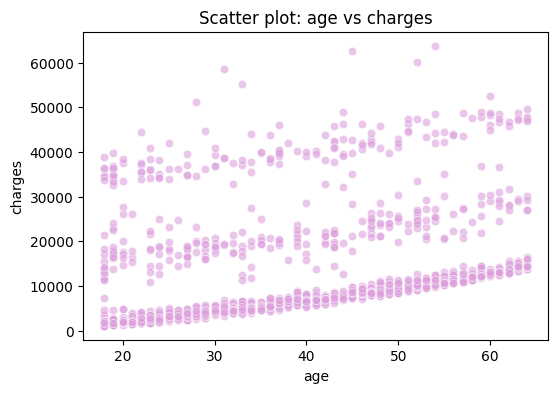

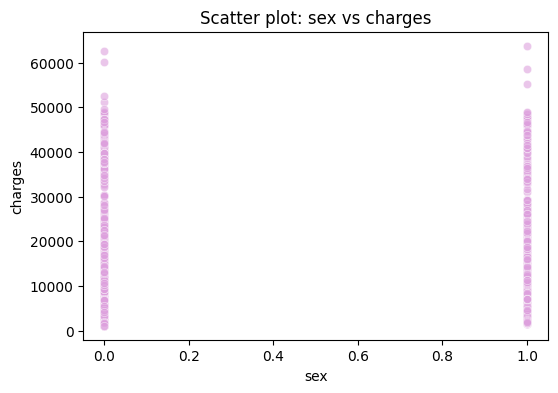

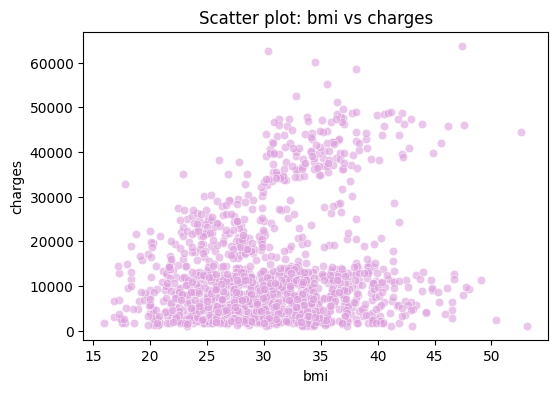

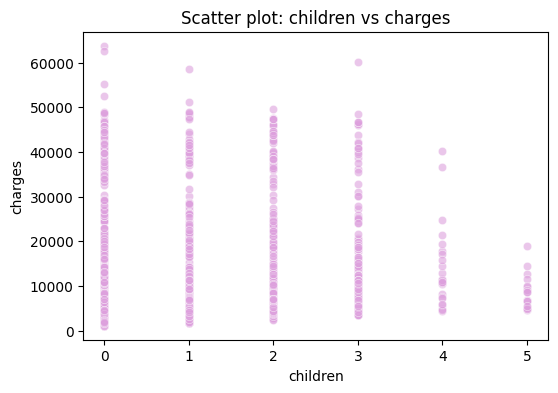

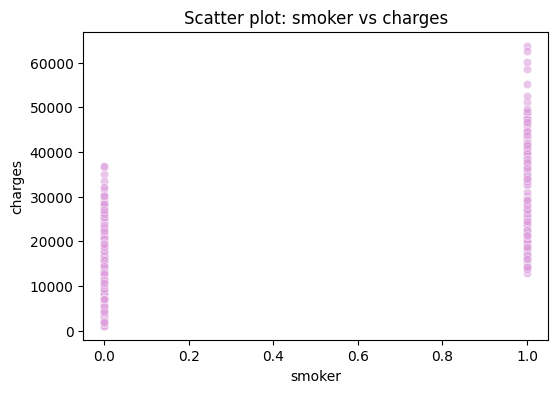

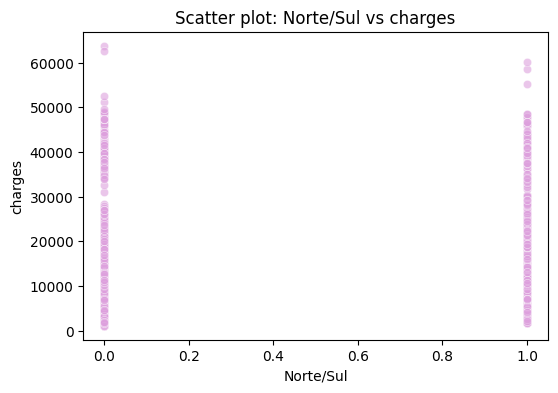

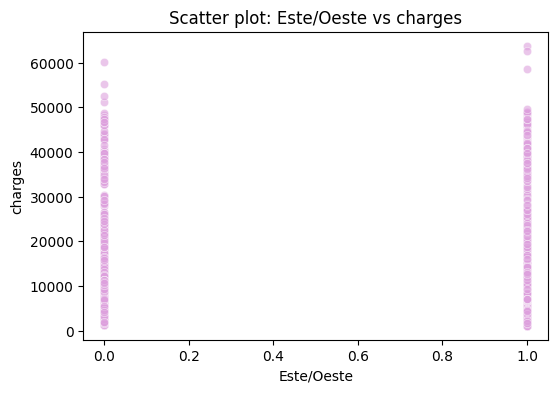

In [ ]:
def scatterplot_dependent(df):
  for col in df.drop("charges", axis=1).columns:
      plt.figure(figsize=(6, 4))
      sns.scatterplot(x=df[col], y=df["charges"], alpha=0.6, color = "plum")
      plt.title(f"Scatter plot: {col} vs charges")
      plt.show()

scatterplot_dependent(df)

***Com base nos scatterplots, podemos concluir que:***

*   As variáveis que mais se destacam são `age`, `smoker`;

*   Podem-se verificar que à medida que se vai envelhecendo, mais despesas em seguro de saúde se vai tendo;

*   Também pode-se verificar que os indivíduos que fumam têm tendência a dispender mais em saúde do que os indivíduos que não fumam;

*   Para além do mais, consegue-se perceber que a variável `bmi` tem a sua relevância, observando-se que quanto maior for o Índice de Massa Corporal, mais são os custos em saúde.

# **Regressão linear**

---



`Normalização dos dados`

In [ ]:
import numpy as np

def prep_data(df, target='charges', mean = None, std = None):
  X = df.drop(columns=[target]).values
  y = df[[target]].values.reshape(-1,1)

  # Normalização de X
  if mean is None or std is None:
    mean = X.mean(axis = 0)
    std = X.std(axis=0)
    std[std == 0] = 1
  X = (X - mean) / std

  # Coluna com bias
  m = X.shape[0]
  bias = np.ones((m, 1))
  X = np.hstack((bias, X))

  return X, y, mean, std

In [ ]:
X, y, _, _ = prep_data(df)
print(X)
print(y)

[[ 1.         -1.43876426  1.0105187  ...  1.97058663 -0.97053843
  -1.0288156 ]
 [ 1.         -1.50996545 -0.98959079 ... -0.5074631  -0.97053843
   0.97199148]
 [ 1.         -0.79795355 -0.98959079 ... -0.5074631  -0.97053843
   0.97199148]
 ...
 [ 1.         -1.50996545  1.0105187  ... -0.5074631  -0.97053843
   0.97199148]
 [ 1.         -1.29636188  1.0105187  ... -0.5074631  -0.97053843
  -1.0288156 ]
 [ 1.          1.55168573  1.0105187  ...  1.97058663  1.0303559
  -1.0288156 ]]
[[16884.924 ]
 [ 1725.5523]
 [ 4449.462 ]
 ...
 [ 1629.8335]
 [ 2007.945 ]
 [29141.3603]]


`Função de custo`

In [ ]:
# Hipótese
import numpy as np

def h(theta,x):
  return np.dot(theta, x)

In [ ]:
import numpy as np

def funcao_custo(X, y, theta):
    m = len(y)
    total = 0
    for i in range(m):
      total += (h(theta, X[i]) - y[i]) ** 2
    return (total / (2*m)).item()

`Descida do gradiente`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def descida_gradiente(X, y, alphas=[0.001, 0.01, 0.1], epochs=100):
    m, n = X.shape

    resultados = {}
    custos_finais = {}

    # Para testar os diferentes valores de alfa
    for alpha in alphas:
        theta = np.zeros(n)
        cost_values = []

        # Loop para cada época
        for epoch in range(epochs):
            grad = np.zeros(n)

            # Cálculo da descida do gradiente
            for i in range(m):
                erro = h(theta, X[i]) - y[i]
                grad += erro * X[i]

            # Média dos gradientes
            grad = grad / m

            # Atualização dos parâmetros
            theta = theta - alpha * grad

            # Cálculo do custo atual
            cost = funcao_custo(X, y, theta)
            cost_values.append(cost)

        final_cost = cost_values[-1]

        resultados[alpha] = {
            "Theta": theta,
            "Costs": cost_values,
            "Final cost": final_cost,
        }

        custos_finais[alpha] = final_cost

        print(f"\nAlpha: {alpha}")
        print(f"Custo final: {float(final_cost):.2f}")


    # Identificar o melhor alfa
    melhor_alpha = min(custos_finais, key=custos_finais.get)
    print(f"\n Melhor alpha encontrado: {melhor_alpha}")

    # Gráfico com todos os alfas
    plt.figure(figsize=(8, 5))
    for alpha in alphas:
        plt.plot(resultados[alpha]["Costs"], label=f"alpha={alpha}")
    plt.xlabel("Épocas")
    plt.ylabel("Custo (MSE)")
    plt.title("Descida do gradiente para diferentes alphas")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráfico com o melhor alfa encontrado
    plt.figure(figsize=(8, 5))
    plt.plot(resultados[melhor_alpha]["Costs"], color="orchid")
    plt.xlabel("Épocas")
    plt.ylabel("Custo (MSE)")
    plt.title(f"Evolução do custo - Melhor alpha ({melhor_alpha})")
    plt.grid(True)
    plt.show()


Alpha: 0.001
Custo final: 135257996.92

Alpha: 0.01
Custo final: 37470977.94

Alpha: 0.1
Custo final: 18256568.37

 Melhor alpha encontrado: 0.1


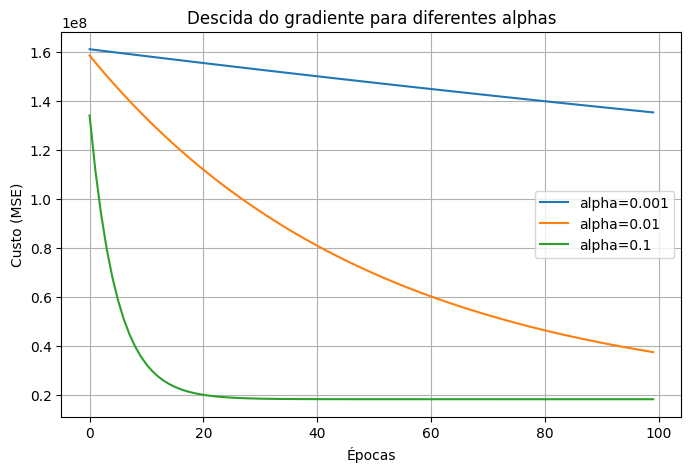

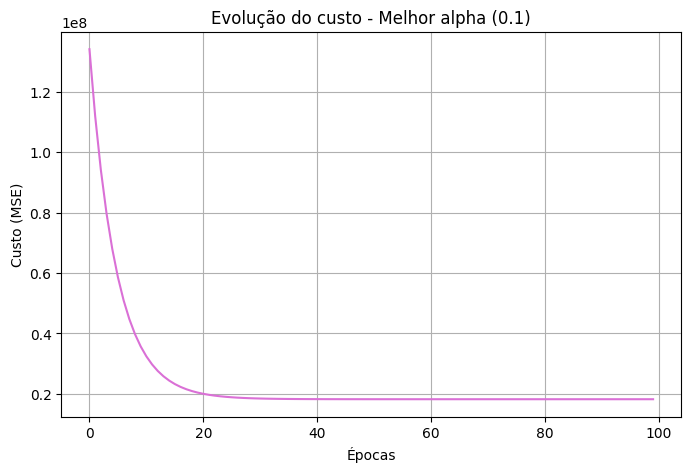

In [ ]:
resultados = descida_gradiente(X, y, alphas=[0.001, 0.01, 0.1], epochs=100)

***Para a regressão linear, foram testados vários valores de alfa, sendo escolhido o `α = 0.1`. Foi escolhido por:***

*   Converger ao fim de 20 épocas;

*   As despesas em saúde desceram rapidamente nas primeiras iterações;

*   O custo final ser mais baixo, perfazendo o total de 18256567.75.

\
O valor `α = 0.001` não foi escolhido, pois ao fim de 200 epócas o modelo não convergiu e atingiu um custo final muito elevado (135257996.92), o que representa uma taxa de aprendizagem pequena.

\
Já `α = 0.01` não foi escolhido pois, apesar de descer mais rapidamente que
α = 0.001, obteve um custo final superior a α = 0.001, sendo ele de 37470977.94.

\
**O número de épocas escolhido para testar o modelo foi 100 para se verificar que o modelo estabiliza a partir das 40 épocas. Logo, <u> o modelo consegue capturar as principais relações entre as variáveis independentes e as despesas em saúde </u>.**

# **Validação empírica**

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def k_fold(df, k = 5, alpha =  0.1, epochs = 100):
  df = df.sample(frac = 1, random_state=50).reset_index(drop=True)
  fold_size = len(df) // k

  r2_values = []
  rmse_values = []
  custos = []
  parametros = []

  for i in range(k):
    # Índices de início e fim do teste
    start = i * fold_size
    end = start + fold_size if i < k - 1 else len(df)

    #Separação dos dados de treino
    df_test = df.iloc[start:end]
    df_train = pd.concat([df.iloc[:start], df.iloc[end:]])

    # Preparação dos dados
    X_train, y_train, mean, std = prep_data(df_train)
    X_test, y_test, _, _ = prep_data(df_test, mean = mean, std = std)

    # Treino do modelo com descida do gradiente
    resultados, _ = descida_gradiente(X_train, y_train, alphas = [alpha], epochs = epochs)
    melhor = resultados[alpha]

    theta = melhor["Theta"]
    custo_final = melhor["Final cost"]

    y_pred = np.array([h(theta, X_test[i],) for i in range(len(X_test))]).reshape(-1, 1)

    # Cálculo do R²
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Cálculo do RMSE
    mse = np.sum((y_test - y_pred) ** 2) / len(y_test)
    rmse = np.sqrt(mse)

    r2_values.append(r2)
    rmse_values.append(rmse)
    custos.append(custo_final)
    parametros.append(theta)

    print(f"\nFold {i+1}:")
    print(f"R² = {r2:.4f}")
    print(f"RMSE = {rmse:.2f}")

  print("\nResumo da validação cruzada:")
  print(f"Média R²: {np.mean(r2_values):.4f}")
  print(f"Desvio padrão R²: {np.std(r2_values):.4f}")
  print(f"Média RMSE: {np.mean(rmse_values):.2f}")
  print(f"Desvio padrão RMSE: {np.std(rmse_values):.2f}")

  # Gráfico R² por fold
  plt.figure(figsize=(8, 5))
  plt.bar(range(1, k+1), r2_values, color="skyblue")
  plt.title("R² por fold")
  plt.xlabel("Fold")
  plt.ylabel("R²")
  plt.ylim(0, 1)
  plt.grid(True)
  plt.show()

  # Gráfico RMSE por fold
  plt.figure(figsize=(8, 5))
  plt.plot(range(1, k+1), rmse_values, marker='o', color="salmon")
  plt.title("RMSE por fold")
  plt.xlabel("Fold")
  plt.ylabel("RMSE")
  plt.grid(True)
  plt.show()


Alpha: 0.1
Custo final: 18547162.93

 Melhor alpha encontrado: 0.1


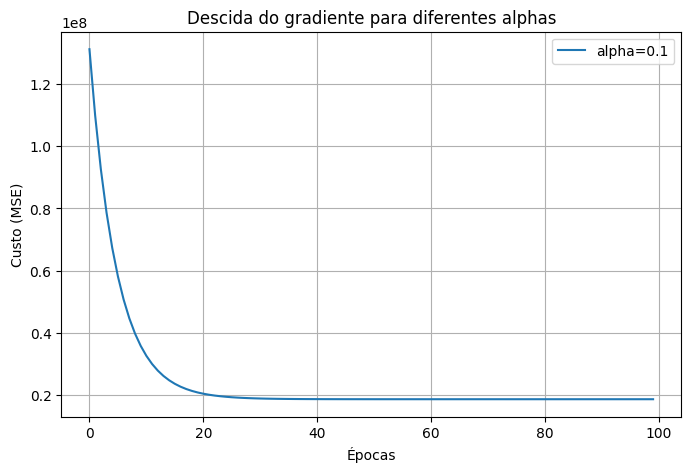

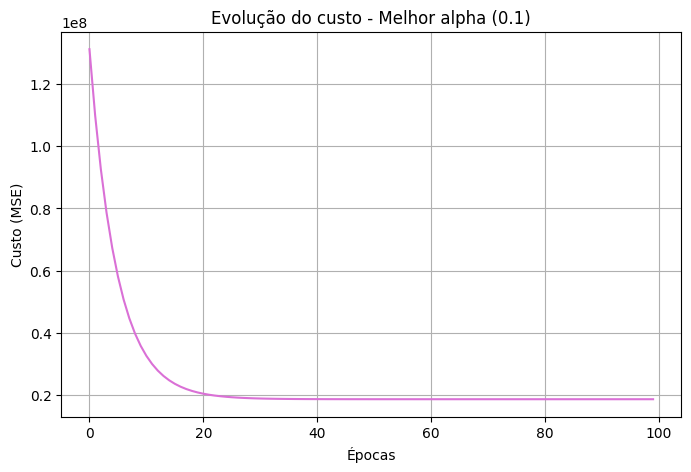


Fold 1:
R² = 0.7822
RMSE = 5882.78

Alpha: 0.1
Custo final: 18568860.80

 Melhor alpha encontrado: 0.1


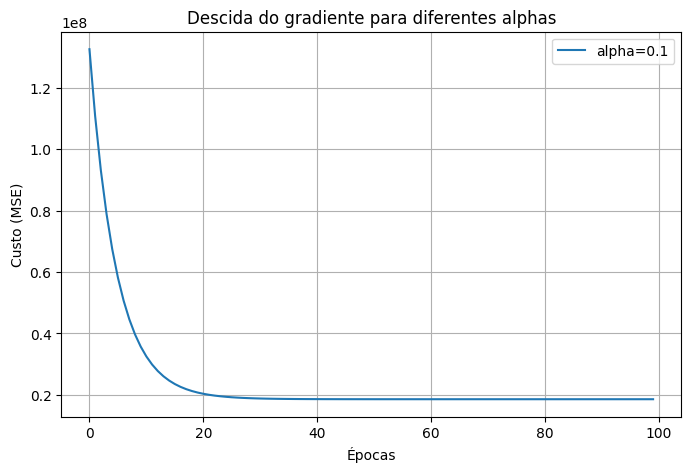

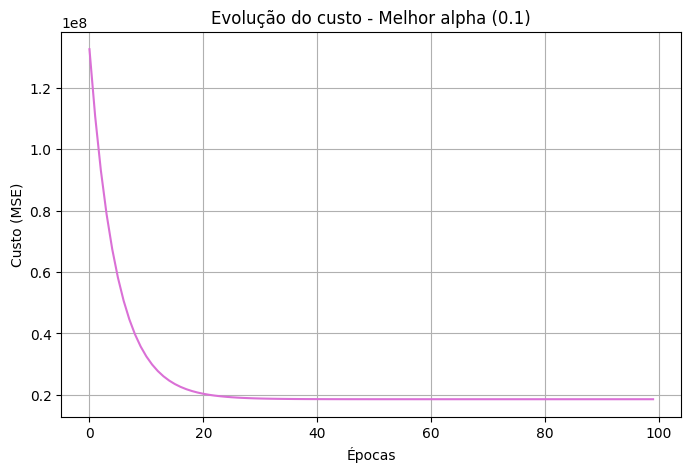


Fold 2:
R² = 0.7717
RMSE = 5841.83

Alpha: 0.1
Custo final: 18492881.40

 Melhor alpha encontrado: 0.1


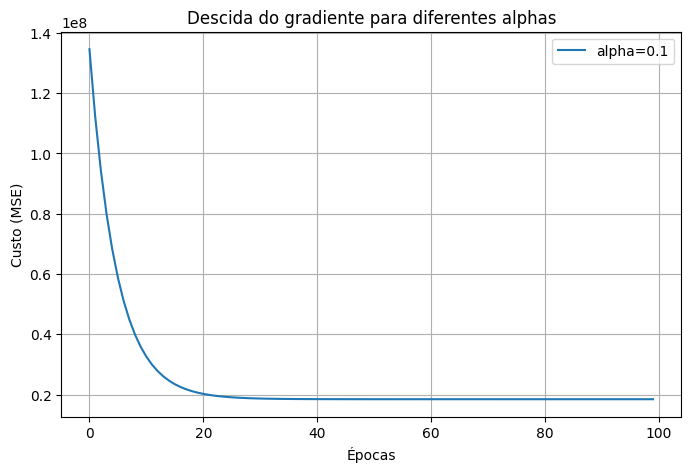

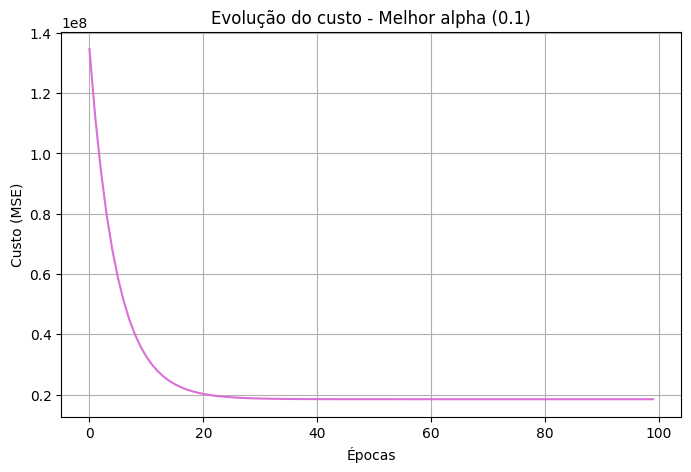


Fold 3:
R² = 0.7604
RMSE = 5895.08

Alpha: 0.1
Custo final: 17328420.99

 Melhor alpha encontrado: 0.1


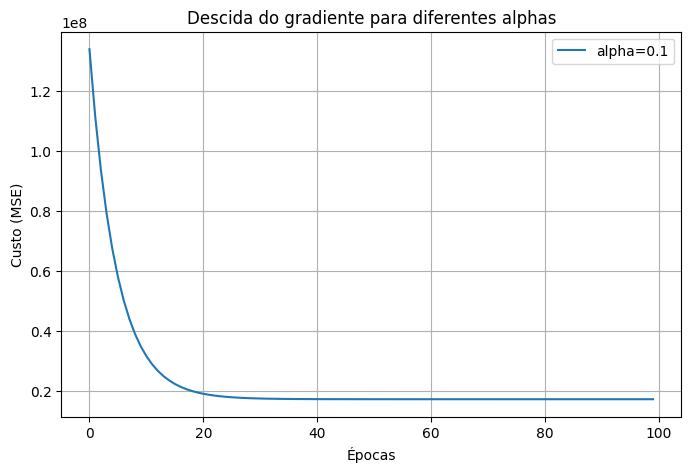

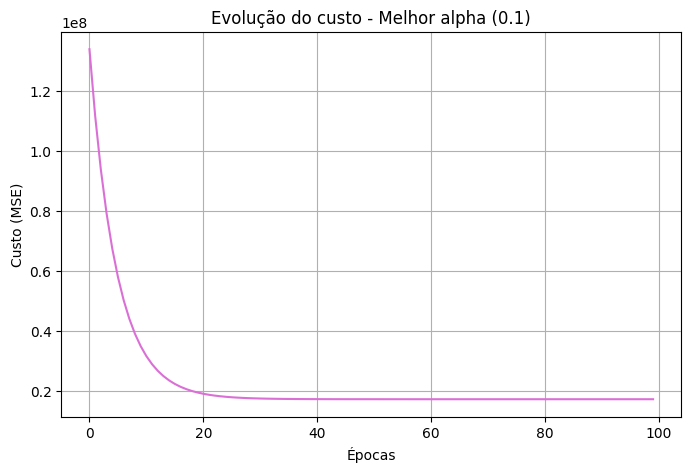


Fold 4:
R² = 0.7134
RMSE = 6647.20

Alpha: 0.1
Custo final: 18194167.96

 Melhor alpha encontrado: 0.1


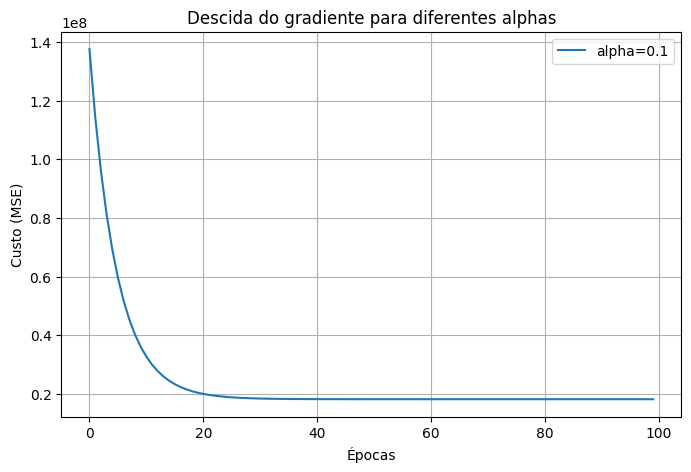

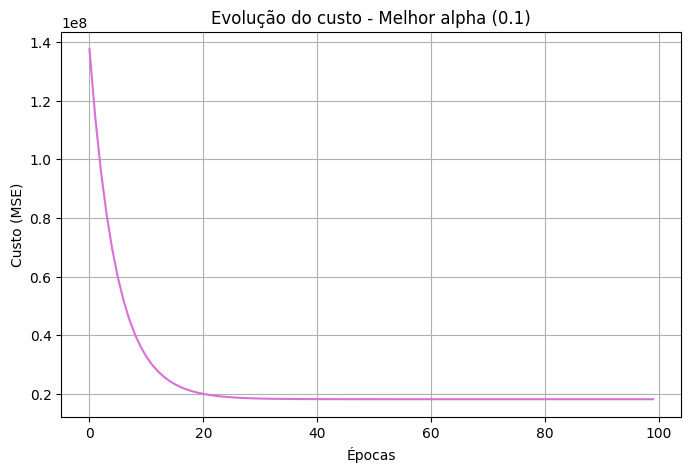


Fold 5:
R² = 0.6975
RMSE = 6134.74

Resumo da validação cruzada:
Média R²: 0.7450
Desvio padrão R²: 0.0334
Média RMSE: 6080.33
Desvio padrão RMSE: 301.50


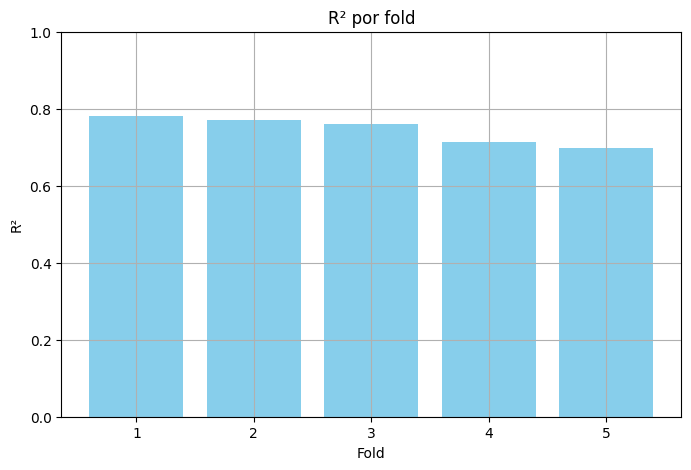

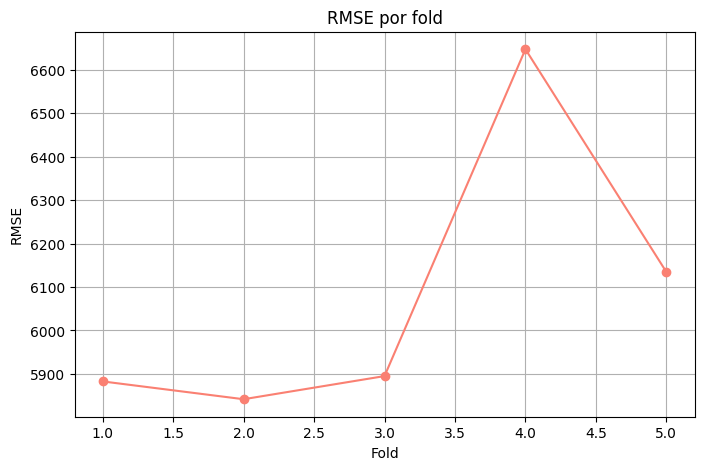

In [ ]:
k_fold(df, k = 5, alpha = 0.1, epochs = 100)

***A validação cruzada consegue concluir que:***

*   O modelo apresenta um bom desempenho médio, com variações aceitáveis entre cada fold;

*   A média dos coeficientes de determinação indica que o modelo explica 74.5% da variabilidade dos dados, tendo uma boa capacidade explicativa;

*   A média do Erro Quadrático Médio é de 6080.33, o que representa um bom erro médio;

*  O fold 4 foi o que representou o pior desempenho, com o R² mais baixo e o RMSE mais elevado.



# **Modelo polinomial**

---



In [ ]:
import numpy as np

def poly(X, p):
  # Cópia da matriz
  X_poly = X.copy()

  # Adiciona termos polinomiais de grau 2 até p (exceto bias)
  for grau in range(2, p + 1):
    X_poly = np.hstack((X_poly, X[:, 1:] ** grau))

  return X_poly

In [ ]:
def prep_data(df, target='charges', p = 2, mean=None, std=None):
  df = df.copy()
  X = df.drop(columns=[target]).values
  y = df[[target]].values.reshape(-1, 1)

  # Normalização dos dados
  if mean is None or std is None:
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1

  X = (X - mean) / std

  # Adiciona coluna de bias
  m = X.shape[0]
  bias = np.ones((m, 1))
  X = np.hstack((bias, X))

  # Expansão polinomial
  if p > 1:
    X = poly(X, p)

  return X, y, mean, std

In [ ]:
def k_fold(df, k=5, alpha=0.1, epochs=100, p = 2):
  # Embaralha os dados para garantir aleatoriedade
  df = df.sample(frac=1, random_state=50).reset_index(drop=True)
  fold_size = len(df) // k

  # Inicializa listas para armazenar métricas
  r2_values = []
  rmse_values = []
  custos = []
  parametros = []

  for i in range(k):
    # Define os subconjuntos de treino e teste
    start = i * fold_size
    end = start + fold_size if i < k - 1 else len(df)

    df_test = df.iloc[start:end]
    df_train = pd.concat([df.iloc[:start], df.iloc[end:]])

    # Pré-processamento com expansão polinomial e normalização
    X_train, y_train, mean, std = prep_data(df_train, p=p)
    X_test, y_test, _, _ = prep_data(df_test, p=p, mean=mean, std=std)

    # Treino com descida do gradiente
    resultados, _ = descida_gradiente(X_train, y_train, alphas=[alpha], epochs=epochs)
    melhor = resultados[alpha]

    theta = melhor["Theta"]
    custo_final = melhor["Final cost"]

    # Previsões no conjunto de teste
    y_pred = np.array([h(theta, X_test[i]) for i in range(len(X_test))]).reshape(-1, 1)

    # Cálculo do R²
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Cálculo do RMSE
    mse = np.sum((y_test - y_pred) ** 2) / len(y_test)
    rmse = np.sqrt(mse)

    # Armazenamento dos resultados
    r2_values.append(r2)
    rmse_values.append(rmse)
    custos.append(custo_final)
    parametros.append(theta)

    print(f"\nFold {i+1}:")
    print(f"R² = {r2:.4f}")
    print(f"RMSE = {rmse:.2f}")

    # Resumo estatístico
    print("\nResumo da validação cruzada:")
    print(f"Média R²: {np.mean(r2_values):.4f}")
    print(f"Desvio padrão R²: {np.std(r2_values):.4f}")
    print(f"Média RMSE: {np.mean(rmse_values):.2f}")
    print(f"Desvio padrão RMSE: {np.std(rmse_values):.2f}")

  # Gráfico R² por fold
  plt.figure(figsize=(8, 5))
  plt.bar(range(1, k + 1), r2_values, color="skyblue")
  plt.title("R² por fold")
  plt.xlabel("Fold")
  plt.ylabel("R²")
  plt.ylim(0, 1)
  plt.grid(True)
  plt.show()

  # Gráfico RMSE por fold
  plt.figure(figsize=(8, 5))
  plt.plot(range(1, k + 1), rmse_values, marker='o', color="salmon")
  plt.title("RMSE por fold")
  plt.xlabel("Fold")
  plt.ylabel("RMSE")
  plt.grid(True)
  plt.show()


Alpha: 0.1
Custo final: 18169925.88

 Melhor alpha encontrado: 0.1


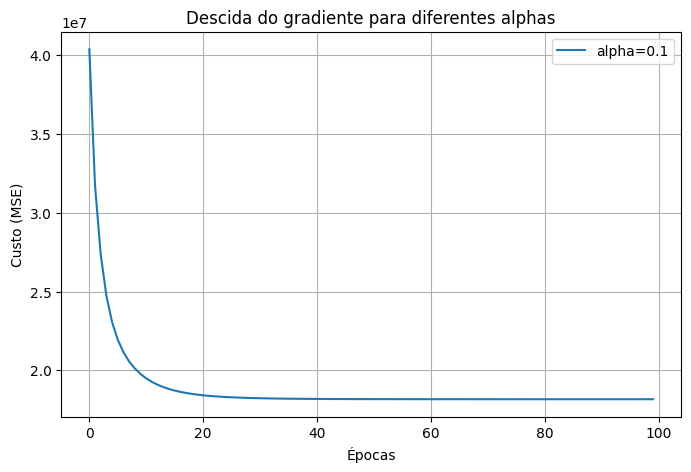

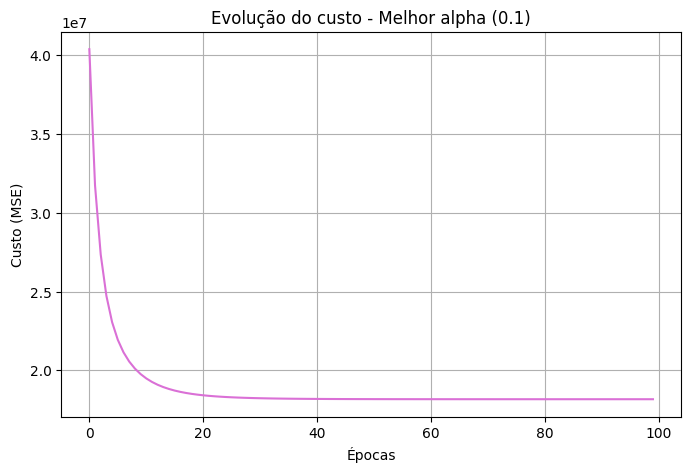


Fold 1:
R² = 0.7829
RMSE = 5872.90

Resumo da validação cruzada:
Média R²: 0.7829
Desvio padrão R²: 0.0000
Média RMSE: 5872.90
Desvio padrão RMSE: 0.00

Alpha: 0.1
Custo final: 18222025.26

 Melhor alpha encontrado: 0.1


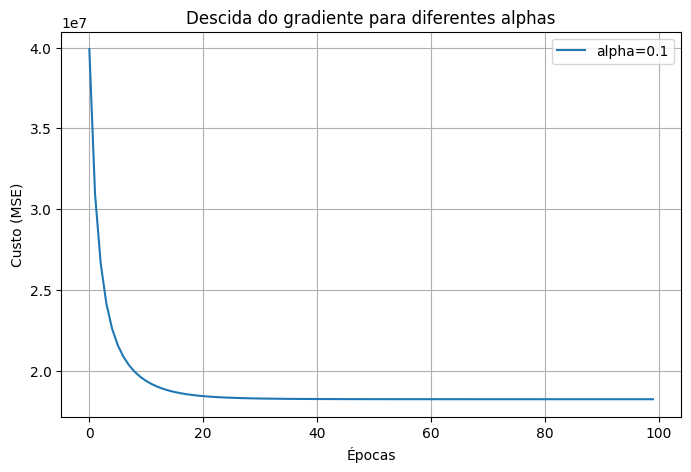

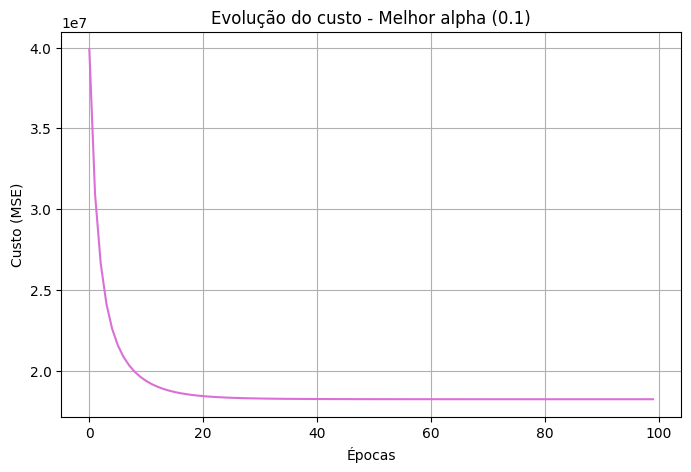


Fold 2:
R² = 0.7728
RMSE = 5827.86

Resumo da validação cruzada:
Média R²: 0.7779
Desvio padrão R²: 0.0051
Média RMSE: 5850.38
Desvio padrão RMSE: 22.52

Alpha: 0.1
Custo final: 18168009.19

 Melhor alpha encontrado: 0.1


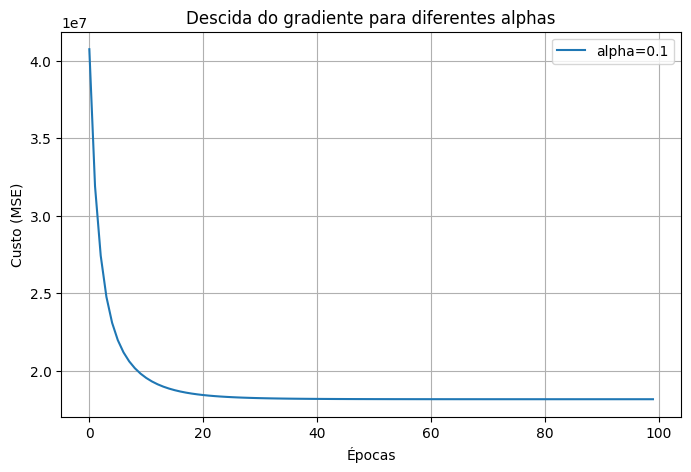

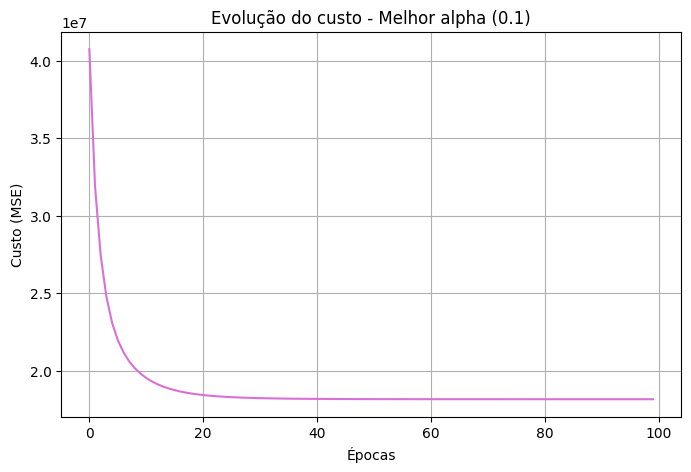


Fold 3:
R² = 0.7641
RMSE = 5849.43

Resumo da validação cruzada:
Média R²: 0.7733
Desvio padrão R²: 0.0077
Média RMSE: 5850.06
Desvio padrão RMSE: 18.40

Alpha: 0.1
Custo final: 16915023.83

 Melhor alpha encontrado: 0.1


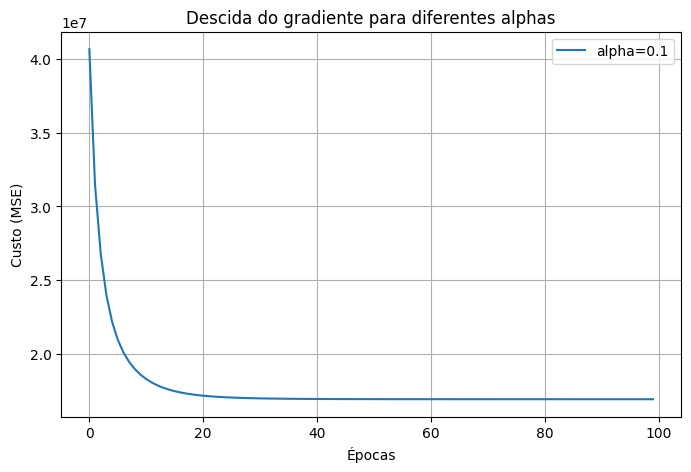

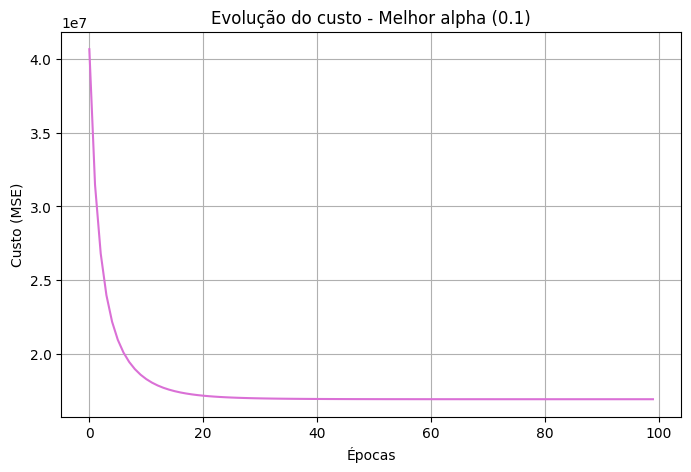


Fold 4:
R² = 0.7123
RMSE = 6659.39

Resumo da validação cruzada:
Média R²: 0.7580
Desvio padrão R²: 0.0272
Média RMSE: 6052.39
Desvio padrão RMSE: 350.81

Alpha: 0.1
Custo final: 18011387.07

 Melhor alpha encontrado: 0.1


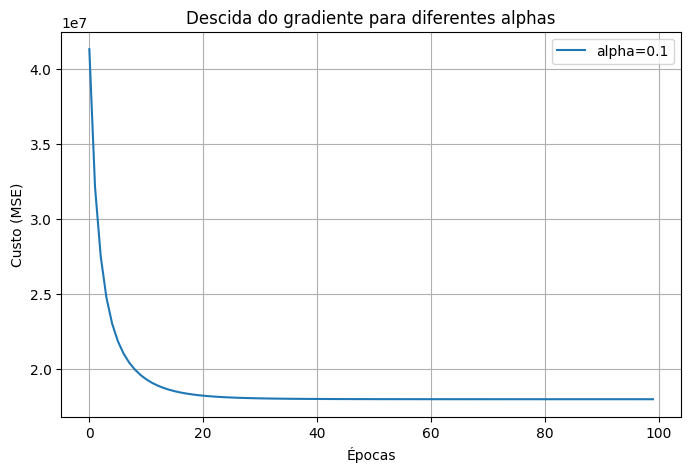

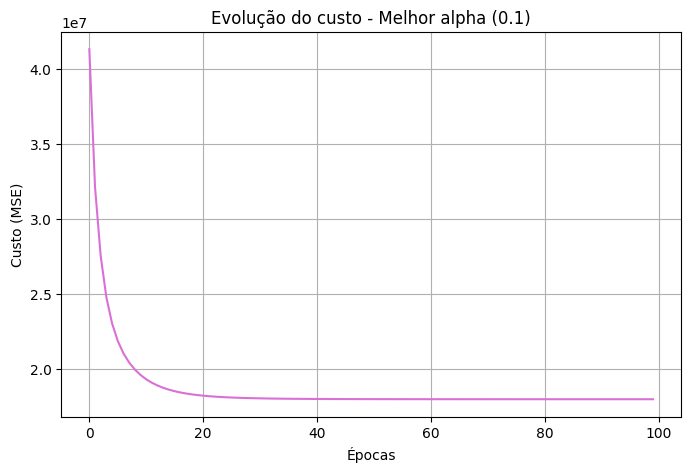


Fold 5:
R² = 0.7091
RMSE = 6016.79

Resumo da validação cruzada:
Média R²: 0.7482
Desvio padrão R²: 0.0313
Média RMSE: 6045.27
Desvio padrão RMSE: 314.10


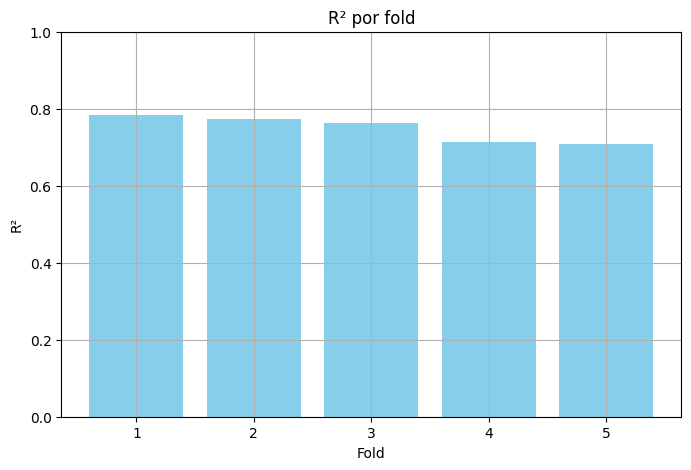

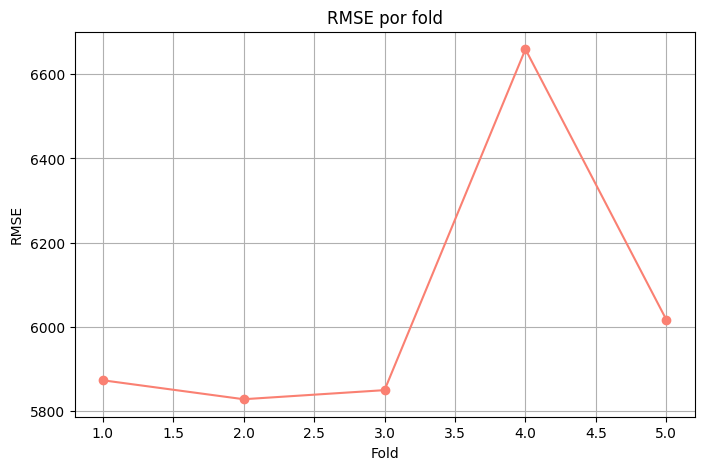

In [ ]:
k_fold(df, k=5, alpha = 0.1, epochs=100, p = 2)

**O algoritmo da descida do gradiente não sofreu alterações** no código pois, como se pôde ver na validação empírica, cada fold apresentou um comportamento estável.

Para o modelo polinomial, usou-se `p=2`, pois ao utilizar outros valores, como o caso de p = 3, o modelo divergia, como se pode ver na seguinte imagem:


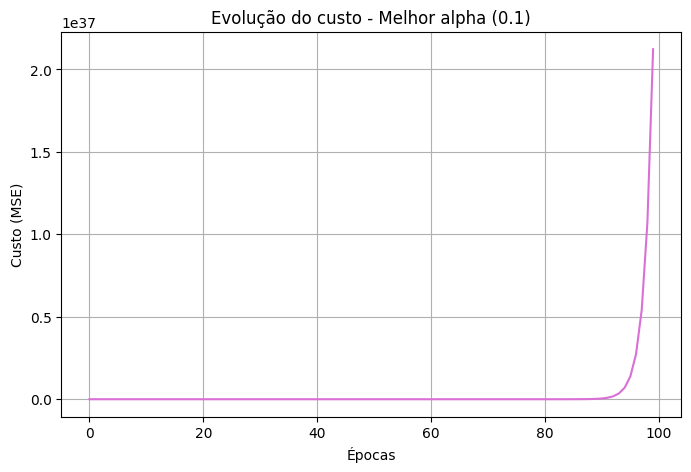

\
Podemos observar que a média do coeficiente de determinação foi de 74,82%, o que representa também uma boa capacidade explicativa, aumentando muito ligeiramente em comparação aos resultados obtidos sem a expansão polinomial. Já a média do Erro Quadrático Médio diminuiu comparativamente aos resultados sem expansão polinomial, sendo 6045,27.

\
Com isto, conseguimos concluir que <u> **o modelo polinomial com p = 2 adapta-se melhor à análise pretendida**</u>, pois consegue ter um melhor desempenho e cometer menos erros.